# Automotive Dataset — Exploratory Data Analysis
---

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

BG_DARK   = '#F2F2F2'
BG_PANEL  = '#FAF9F6'
ACCENT    = '#58a6ff'
TEXT      = '#090a0a'
GRID      = '#30363d'

CAT_PALETTE = [
    '#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657',
    '#79c0ff', '#56d364', '#ff7b72', '#bc8cff', '#e3b341',
    '#2ea043', '#1f6feb', '#da3633'
]

plt.rcParams.update({
    'figure.facecolor':  BG_DARK,
    'axes.facecolor':    BG_PANEL,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   TEXT,
    'axes.titlecolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        GRID,
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'legend.facecolor':  BG_PANEL,
    'legend.edgecolor':  GRID,
    'figure.figsize':    (14, 6),
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.titlesize':    13,
})


In [19]:
df = pd.read_csv('/content/data.csv')
print(f'Loaded: ', df.shape)
df.head()

Loaded:  (11914, 16)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


---
## I. Data Structure & Distribution

In [20]:
temporal_cols   = [c for c in df.columns if df[c].dtype in ['int64','float64']
                   and 'year' in c.lower()]
num_cols        = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols        = df.select_dtypes(include='object').columns.tolist()

ordinal_cat  = [c for c in cat_cols if df[c].nunique() <= 6]
nominal_cat  = [c for c in cat_cols if df[c].nunique() >  6]
cont_num     = [c for c in num_cols if c not in temporal_cols]

print('── Variable Registry ──────────────────────────────')
print(f'  Temporal            : {temporal_cols}')
print(f'  Nominal Categorical : {nominal_cat}')
print(f'  Ordinal Categorical : {ordinal_cat}')
print(f'  Continuous Numerical: {cont_num}')
print()
print(f'Shape  : {df.shape}')
print(f'Memory : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')
print()
df.dtypes.value_counts().rename('count').to_frame()

── Variable Registry ──────────────────────────────
  Temporal            : ['Year']
  Nominal Categorical : ['Make', 'Model', 'Engine Fuel Type', 'Market Category', 'Vehicle Style']
  Ordinal Categorical : ['Transmission Type', 'Driven_Wheels', 'Vehicle Size']
  Continuous Numerical: ['Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']

Shape  : (11914, 16)
Memory : 6.08 MB



,count
object,8
int64,5
float64,3


---
## II. Statistical Profiling

In [21]:
profile_rows = []
for col in cont_num:
    s = df[col].dropna()
    profile_rows.append({
        'Feature'    : col,
        'Mean'       : round(s.mean(), 3),
        'Median'     : round(s.median(), 3),
        'Mean-Median': round(s.mean() - s.median(), 3),
        'Skewness'   : round(skew(s), 3),
        'Kurtosis'   : round(kurtosis(s), 3),
    })

profile_df = pd.DataFrame(profile_rows).set_index('Feature')

def _skew_label(v):  return 'Highly Skewed' if abs(v)>1 else ('Mod. Skewed' if abs(v)>0.5 else 'Symmetric')
def _kurt_label(v):  return 'Leptokurtic'  if v>1    else ('Platykurtic' if v<0 else 'Mesokurtic')

profile_df['Skew Label']  = profile_df['Skewness'].apply(_skew_label)
profile_df['Kurt Label']  = profile_df['Kurtosis'].apply(_kurt_label)

profile_df

,Mean,Median,Mean-Median,Skewness,Kurtosis,Skew Label,Kurt Label
Feature,,,,,,,
Engine HP,249.386,227.0,22.386,1.291,2.322,Highly Skewed,Leptokurtic
Engine Cylinders,5.629,6.0,-0.371,0.964,1.973,Mod. Skewed,Leptokurtic
Number of Doors,3.436,4.0,-0.564,-0.969,-1.009,Mod. Skewed,Platykurtic
highway MPG,26.637,26.0,0.637,7.573,181.551,Highly Skewed,Leptokurtic
city mpg,19.733,18.0,1.733,7.106,74.592,Highly Skewed,Leptokurtic
Popularity,1554.911,1385.0,169.911,1.653,2.276,Highly Skewed,Leptokurtic
MSRP,40594.737,29995.0,10599.737,11.771,268.813,Highly Skewed,Leptokurtic


---
## III. Missing Data Management

In [22]:
miss = pd.DataFrame({
    'Count'  : df.isnull().sum(),
    'Pct'    : (df.isnull().mean() * 100).round(2)
}).query('Count > 0').sort_values('Pct', ascending=False)

print(miss.to_string() if len(miss) else '✓ No missing values')

                  Count    Pct
Market Category    3742  31.41
Engine HP            69   0.58
Engine Cylinders     30   0.25
Number of Doors       6   0.05
Engine Fuel Type      3   0.03


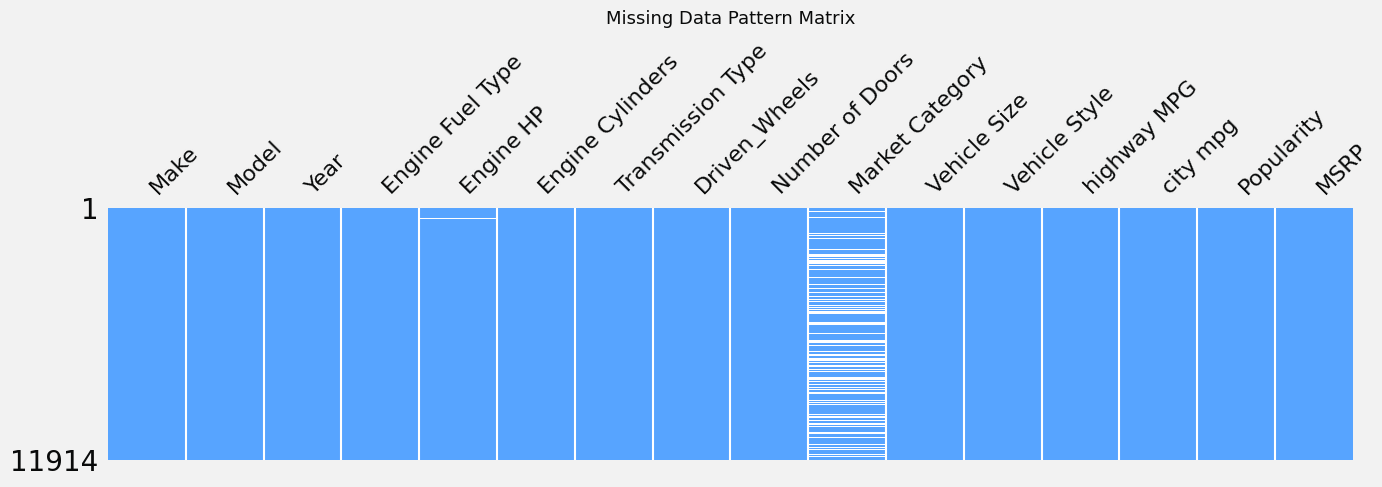

In [23]:
if len(miss):
    fig, ax = plt.subplots(figsize=(14, 5))
    msno.matrix(df, ax=ax, sparkline=False, color=(0.345, 0.647, 1.0))
    ax.set_title('Missing Data Pattern Matrix', pad=12)
    plt.tight_layout()
    plt.show()

In [24]:
df_clean = df.copy()

group_col = ordinal_cat[0] if ordinal_cat else None

for col in cont_num:
    if df_clean[col].isnull().any():
        if group_col and group_col in df_clean.columns:
            df_clean[col] = df_clean.groupby(group_col)[col].transform(
                lambda x: x.fillna(x.median())
            )
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

remaining_miss = df_clean[cont_num].isnull().sum().sum()
print(f'Imputation complete. Remaining nulls in numerical cols: {remaining_miss}')

Imputation complete. Remaining nulls in numerical cols: 0


---
## IV. Probability Density Estimation

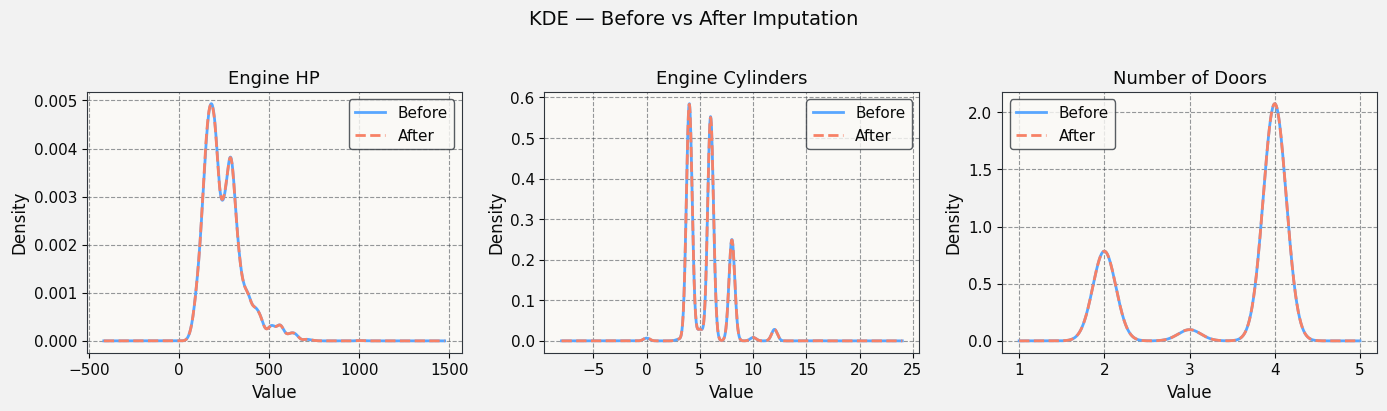

In [25]:
cols_with_imputed = [c for c in cont_num if df[c].isnull().any()]
plot_cols = cols_with_imputed if cols_with_imputed else cont_num[:6]

ncols = 3
nrows = (len(plot_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    df[col].dropna().plot(kind='kde', ax=ax, color=ACCENT,     lw=2, label='Before')
    df_clean[col].plot(  kind='kde', ax=ax, color=CAT_PALETTE[2], lw=2, ls='--', label='After')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.legend()
    ax.grid(True)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('KDE — Before vs After Imputation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## V. Outlier Engineering

In [26]:
outlier_rows = []
for col in cont_num:
    s = df_clean[col]
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    iqr_out  = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
    z_out    = (np.abs(stats.zscore(s)) > 3).sum()
    outlier_rows.append({
        'Feature'       : col,
        'IQR Outliers'  : iqr_out,
        'IQR Pct'       : round(iqr_out / len(s) * 100, 2),
        'Z>3 Outliers'  : z_out,
        'Z>3 Pct'       : round(z_out / len(s) * 100, 2),
    })

pd.DataFrame(outlier_rows).set_index('Feature')

,IQR Outliers,IQR Pct,Z>3 Outliers,Z>3 Pct
Feature,,,,
Engine HP,509,4.27,190,1.59
Engine Cylinders,367,3.08,299,2.51
Number of Doors,0,0.00,0,0.00
highway MPG,192,1.61,67,0.56
city mpg,316,2.65,112,0.94
Popularity,881,7.39,0,0.00
MSRP,996,8.36,219,1.84


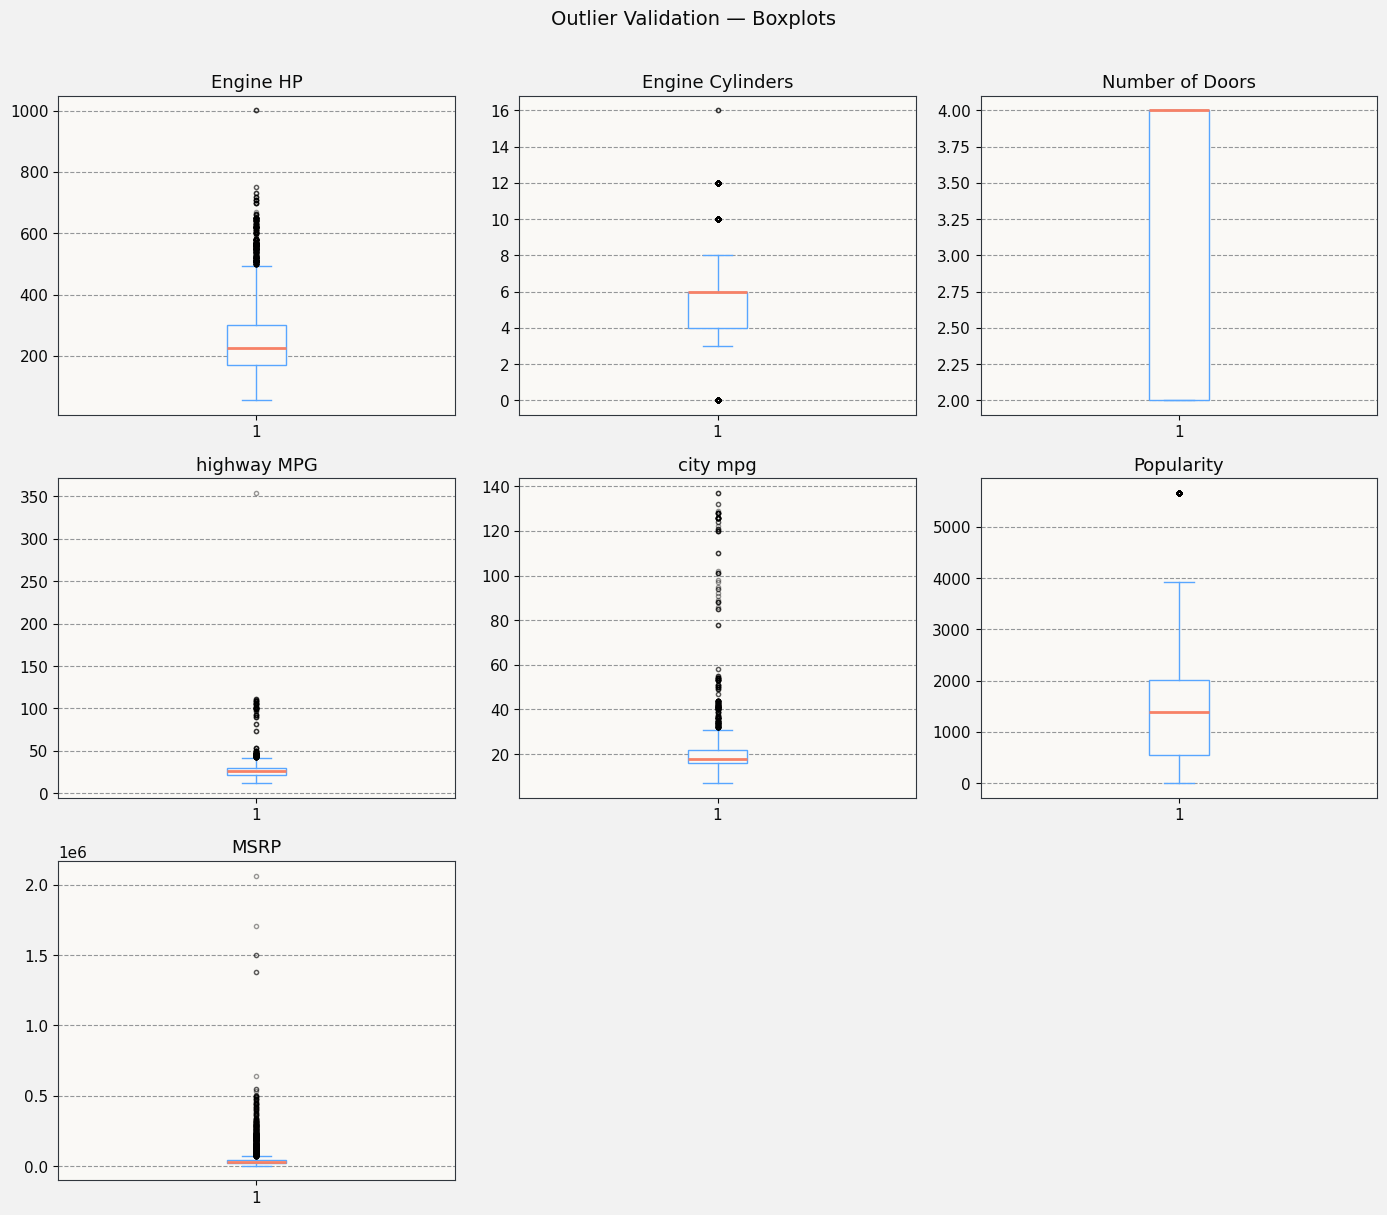

In [27]:
ncols = 3
nrows = (len(cont_num) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).ravel()

bp_props = dict(
    boxprops    = dict(facecolor=BG_PANEL, color=ACCENT),
    medianprops = dict(color=CAT_PALETTE[2], linewidth=2),
    whiskerprops= dict(color=ACCENT),
    capprops    = dict(color=ACCENT),
    flierprops  = dict(marker='o', color=CAT_PALETTE[2], alpha=0.4, markersize=3)
)

for i, col in enumerate(cont_num):
    axes[i].boxplot(df_clean[col].dropna(), vert=True, patch_artist=True, **bp_props)
    axes[i].set_title(col)
    axes[i].grid(True, axis='y')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Outlier Validation — Boxplots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [28]:
df_winsor = df_clean.copy()
for col in cont_num:
    cap = df_winsor[col].quantile(0.99)
    df_winsor[col] = df_winsor[col].clip(upper=cap)

print('✓ Winsorization applied (99th percentile cap) to all continuous numerical features')

✓ Winsorization applied (99th percentile cap) to all continuous numerical features


---
## VI. Univariate & Bivariate Exploration

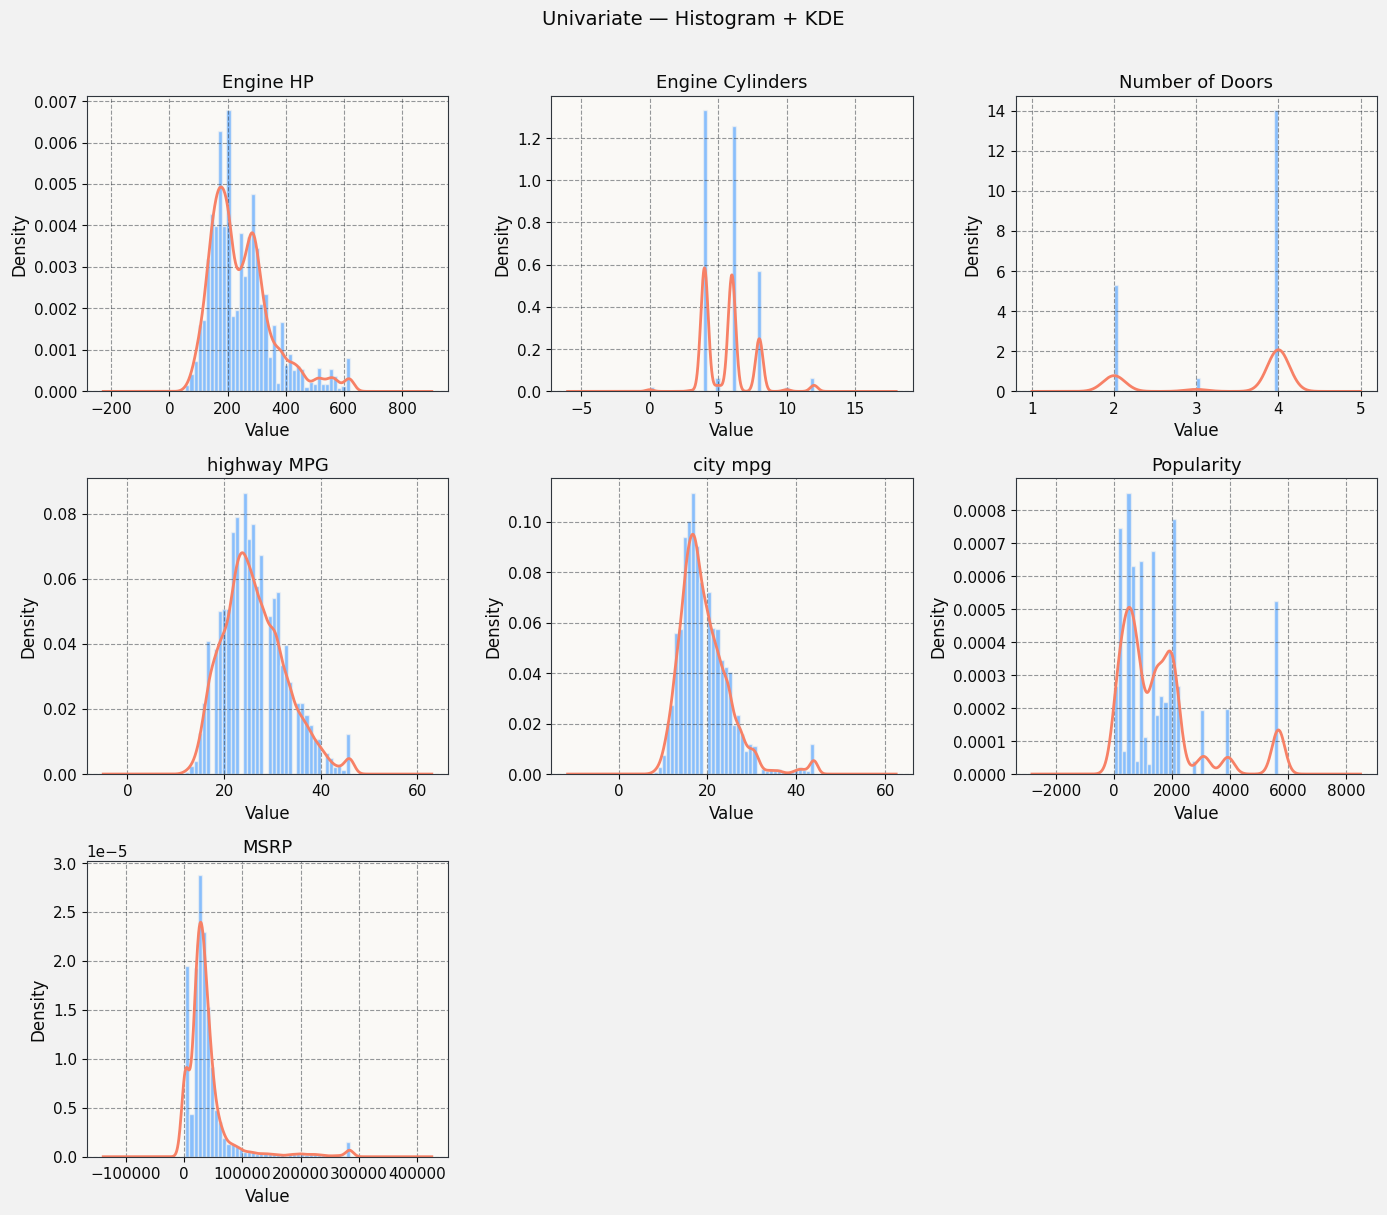

In [29]:
ncols = 3
nrows = (len(cont_num) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(cont_num):
    ax = axes[i]
    ax.hist(df_winsor[col].dropna(), bins=40, color=ACCENT, alpha=0.7, edgecolor=BG_DARK, density=True)
    df_winsor[col].dropna().plot(kind='kde', ax=ax, color=CAT_PALETTE[2], lw=2)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.grid(True)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Univariate — Histogram + KDE', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

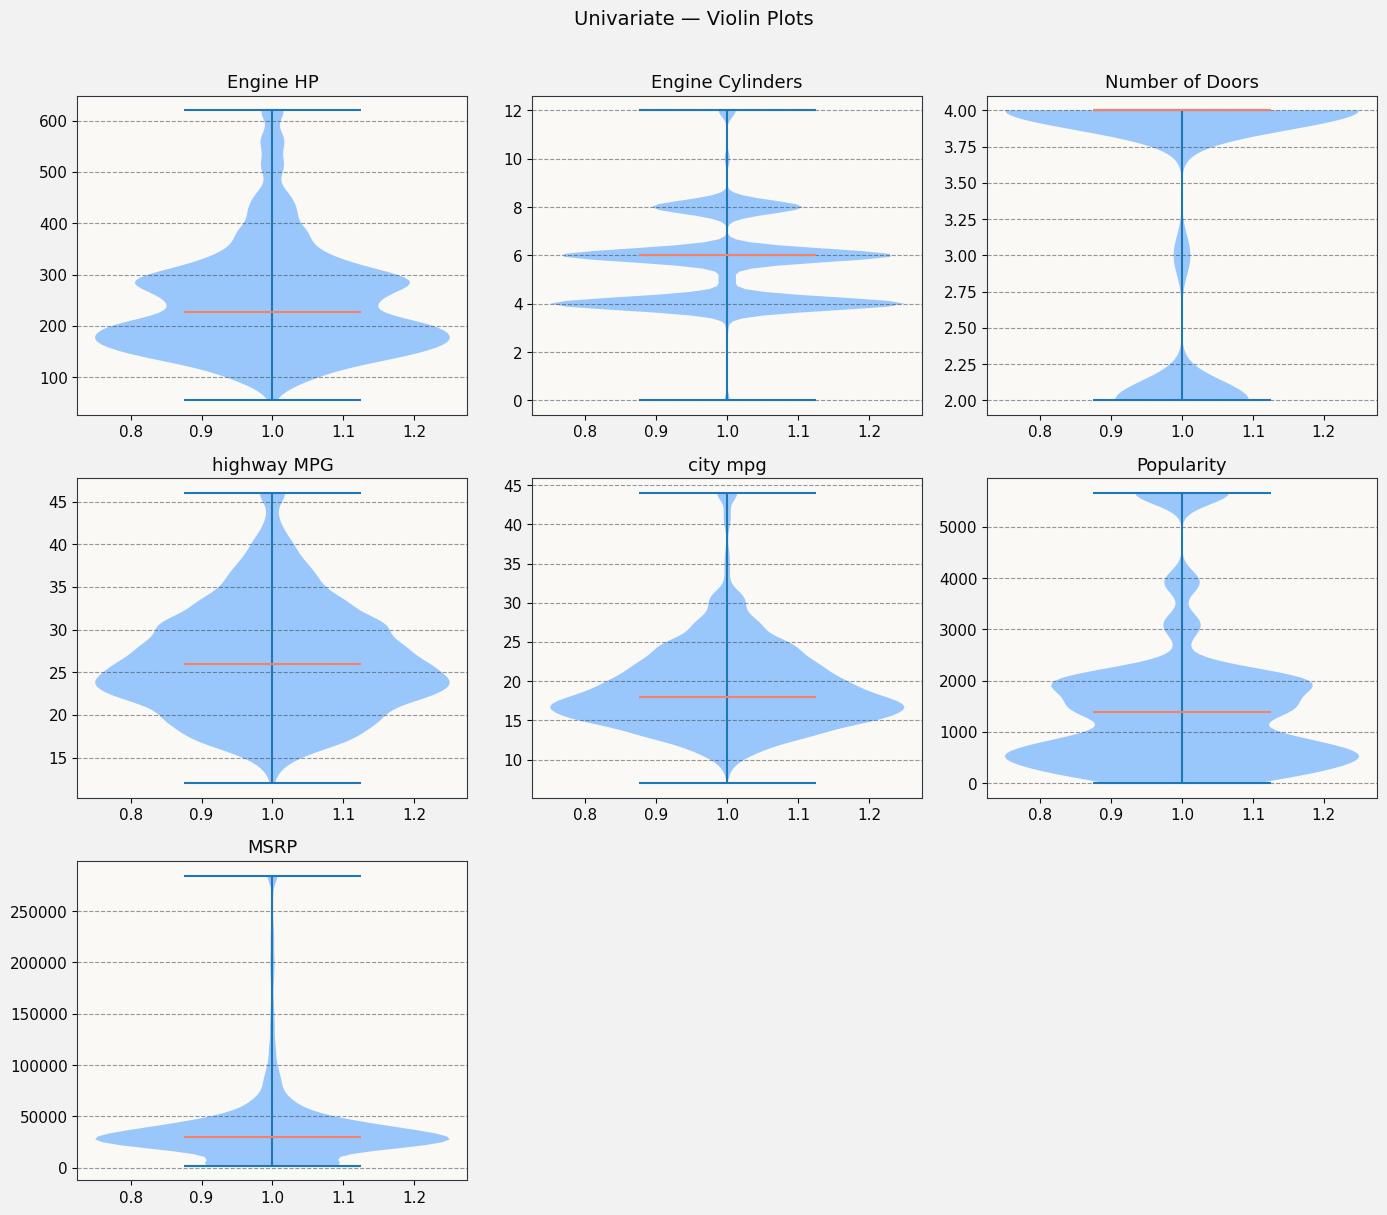

In [30]:
ncols = 3
nrows = (len(cont_num) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(cont_num):
    data = df_winsor[col].dropna()
    parts = axes[i].violinplot(data, vert=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(ACCENT)
        pc.set_alpha(0.6)
    parts['cmedians'].set_color(CAT_PALETTE[2])
    axes[i].set_title(col)
    axes[i].grid(True, axis='y')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Univariate — Violin Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

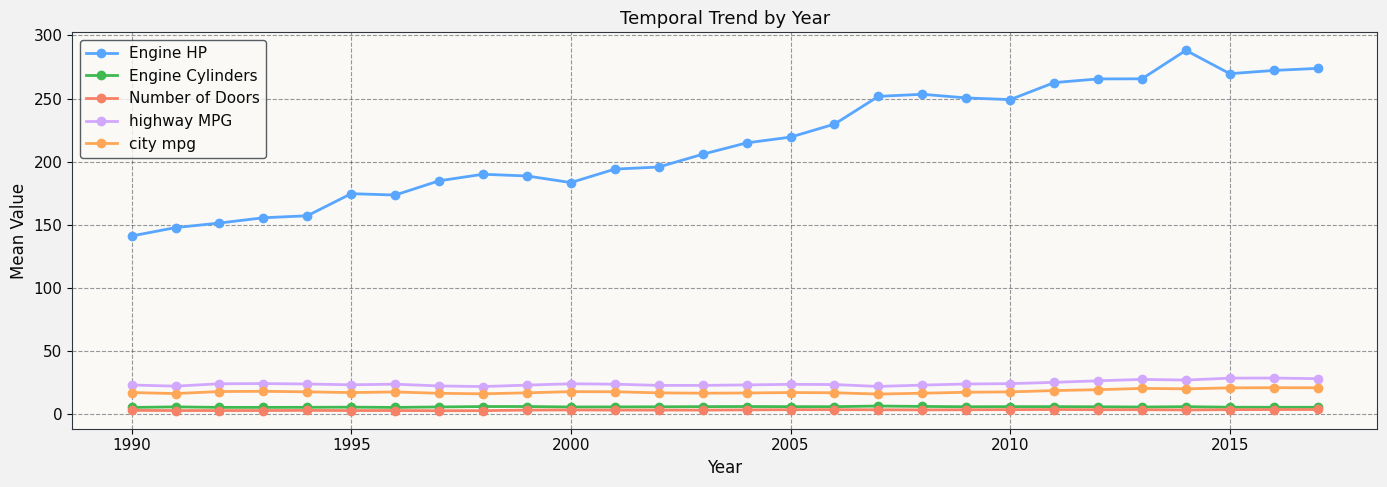

In [31]:
if temporal_cols:
    time_col = temporal_cols[0]
    target_col = cont_num[0]   # swap for your actual target if needed

    monthly = df_winsor.groupby(time_col)[cont_num].mean()

    fig, ax = plt.subplots(figsize=(14, 5))
    for j, col in enumerate(cont_num[:5]):
        ax.plot(monthly.index, monthly[col], marker='o', lw=2,
                color=CAT_PALETTE[j % len(CAT_PALETTE)], label=col)
    ax.set_xlabel(time_col)
    ax.set_ylabel('Mean Value')
    ax.set_title(f'Temporal Trend by {time_col}')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print('No temporal column detected — skipping trend chart.')

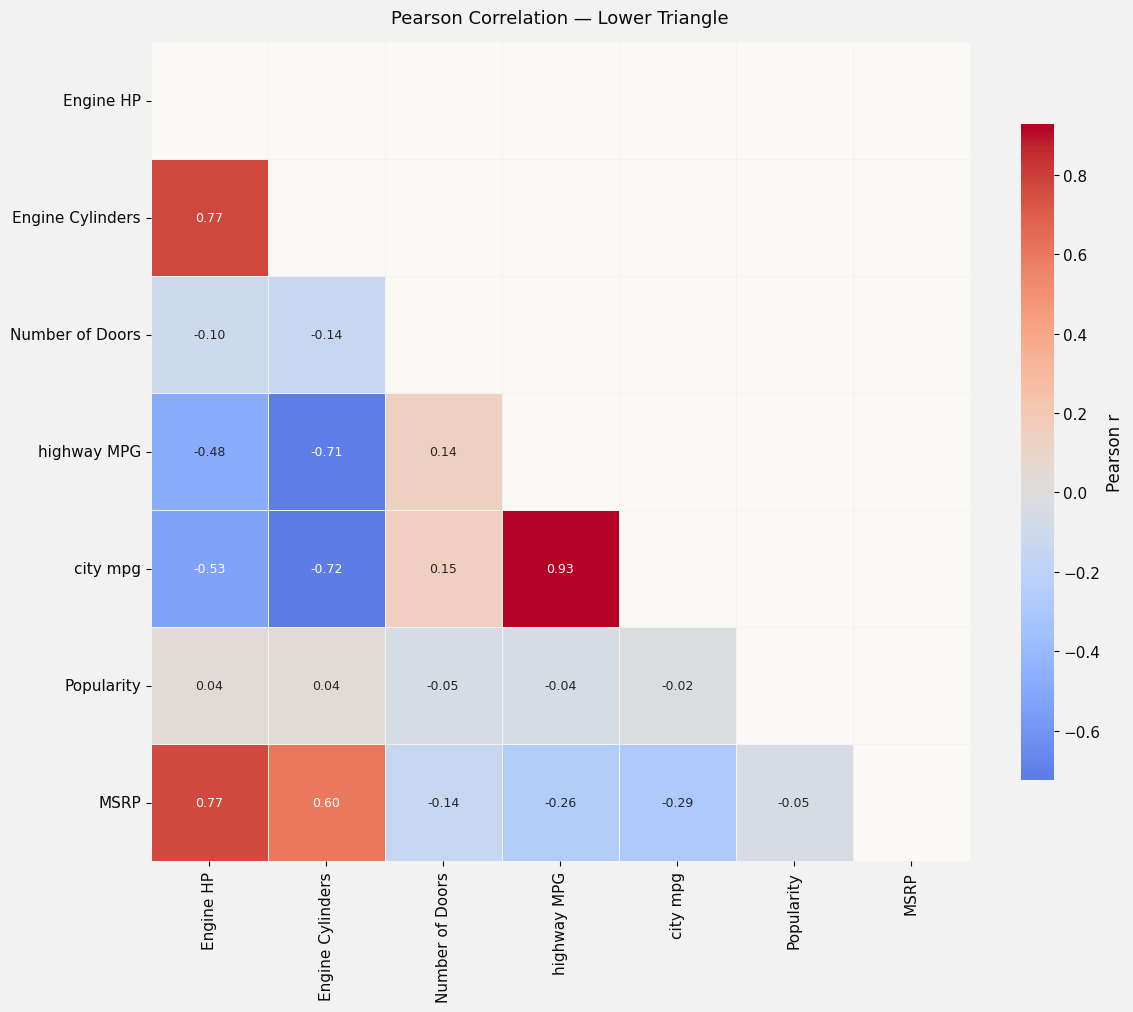

Pairs with |r| > 0.9 (multicollinearity candidates):
    Var1        Var2       r
city mpg highway MPG 0.92679


In [32]:
corr = df_winsor[cont_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    linecolor=BG_DARK, square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Pearson Correlation — Lower Triangle', pad=14)
plt.tight_layout()
plt.show()

high_mc = (
    corr.abs()
    .where(~mask)
    .stack()
    .reset_index()
    .rename(columns={0: 'r', 'level_0': 'Var1', 'level_1': 'Var2'})
    .query('r > 0.9')
    .sort_values('r', ascending=False)
)
if len(high_mc):
    print('Pairs with |r| > 0.9 (multicollinearity candidates):')
    print(high_mc.to_string(index=False))
else:
    print('No pairs exceed |r| = 0.9')

---
## VII. Normalisation & Transformation

In [33]:
SKEW_THRESHOLD = 1.0
skewed_cols = [
    col for col in cont_num
    if skew(df_winsor[col].dropna()) > SKEW_THRESHOLD
]

df_final = df_winsor.copy()
for col in skewed_cols:
    df_final[f'{col}_log'] = np.log1p(df_final[col])

print(f'Log-transformed features ({len(skewed_cols)}): {skewed_cols}')

Log-transformed features (4): ['Engine HP', 'city mpg', 'Popularity', 'MSRP']


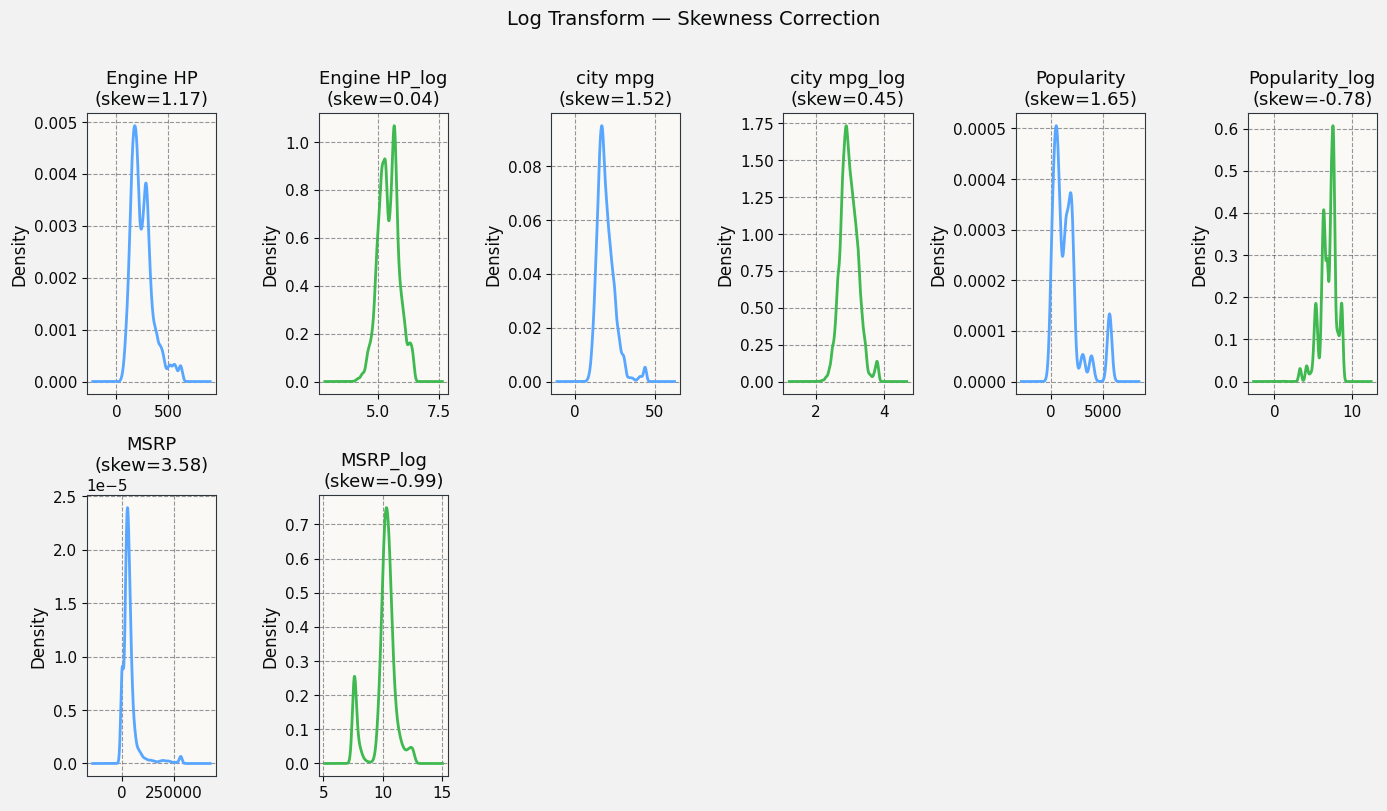

In [34]:
if skewed_cols:
    ncols = min(3, len(skewed_cols))
    nrows = (len(skewed_cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols * 2, figsize=(14, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, col in enumerate(skewed_cols):
        ax_raw = axes[i * 2]
        ax_log = axes[i * 2 + 1]

        df_final[col].plot(kind='kde', ax=ax_raw, color=ACCENT, lw=2)
        ax_raw.set_title(f'{col}\n(skew={skew(df_final[col].dropna()):.2f})')
        ax_raw.grid(True)

        df_final[f'{col}_log'].plot(kind='kde', ax=ax_log, color=CAT_PALETTE[1], lw=2)
        ax_log.set_title(f'{col}_log\n(skew={skew(df_final[col+"_log"].dropna()):.2f})')
        ax_log.grid(True)

    for j in range(i * 2 + 2, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Log Transform — Skewness Correction', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()